# **Predict whether an individual earns above or below $50,000 annually using socioeconomic attributes**

Government agencies and research organizations routinely need to understand the economic divide in populations. Predicting income brackets from demographic and professional attributes provides a scalable, data-driven method to segment the workforce and derive actionable intelligence.

Unlike surveys which are expensive and time-consuming, a trained machine learning model can infer income categories in real-time, enabling continuous monitoring of economic trends at scale.

- **Policy Making**
Identify underserved income groups to design targeted welfare and taxation policies.
- **Workforce Planning**
Help HR and recruiters understand compensation norms across education and occupation levels.
- **Economic Research**
Quantify income inequality by age, race, sex, and geography for academic studies.
- **Market Segmentation**
Segment consumers into income cohorts to personalize financial products and services.

### **dataset link** -- https://drive.google.com/file/d/1GvPfX3GZ052VUQYuNXJ4y31hYK4h9n-x/view?usp=drive_link

In [ ]:
# Hints:-

# 1. Explore the dataset using basic pandas commands and decide which algorithm would be good based on data, problem and target
# 2. rename the columns annual income to some short name - optional
# 3. Explore the values inside object type columns
# 4. Replace any noise value(incorrect value, special characters) with np.nan -- df=df.replace("?",np.nan)
# 5. Check and handle null and duplicates
# 6. Check and remove outliers -- hours-per-week,age,education-num,fnlwgt
# 7. Apply encoding
# 8. Split data into input and output
# 9. Split into training and testing
# 10. Create model
# 11. Train the model
# 12. Evaluate the model

https://docs.google.com/forms/d/e/1FAIpQLSfCSDN5SUF50u6m2E01892siQPBkoZGf4UtpYeGRwQCL1WFUg/viewform

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("/content/census-income .csv")

In [ ]:
df.select_dtypes(include="object").columns

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'annual_income'],
      dtype='object')

In [ ]:
for col in df.select_dtypes(include="object"):
    print(col)
    print(df[col].value_counts())

workclass
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64
education
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64
marital-status
marital-status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64
occupation
occupation
Prof-specialty       4140
C

In [ ]:
df = df.replace("?", np.nan)

In [ ]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1843
relationship,0
race,0
sex,0


In [ ]:
df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

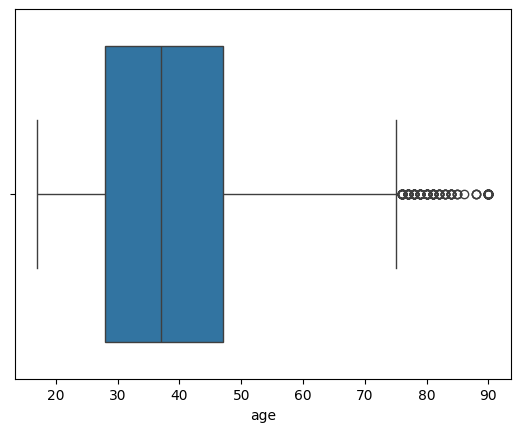

In [ ]:
sns.boxplot(x=df["age"])
plt.show()

In [ ]:
Q1 = df["age"].quantile(0.25)
Q3 = df["age"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["age"] >= lower) & (df["age"] <= upper)]

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
df.columns

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'workclass_Local-gov', 'workclass_Private',
       'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc',
       'workclass_State-gov', 'workclass_Without-pay', 'education_11th',
       'education_12th', 'education_1st-4th', 'education_5th-6th',
       'education_7th-8th', 'education_9th', 'education_Assoc-acdm',
       'education_Assoc-voc', 'education_Bachelors', 'education_Doctorate',
       'education_HS-grad', 'education_Masters', 'education_Preschool',
       'education_Prof-school', 'education_Some-college',
       'marital-status_Married-AF-spouse', 'marital-status_Married-civ-spouse',
       'marital-status_Married-spouse-absent', 'marital-status_Never-married',
       'marital-status_Separated', 'marital-status_Widowed',
       'occupation_Armed-Forces', 'occupation_Craft-repair',
       'occupation_Exec-managerial', 'occupation_Farming-fishing',
       'occupation_Handlers-clea

In [ ]:
X = df.drop("annual_income_>50K", axis=1)
y = df["annual_income_>50K"]

In [ ]:
print(X.shape)
print(y.shape)

(29971, 96)
(29971,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(23976, 96)
(5995, 96)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

In [ ]:
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8146788990825689
              precision    recall  f1-score   support

       False       0.89      0.87      0.88      4544
        True       0.61      0.66      0.63      1451

    accuracy                           0.81      5995
   macro avg       0.75      0.76      0.75      5995
weighted avg       0.82      0.81      0.82      5995

[[3932  612]
 [ 499  952]]
